# Data Annotation with DagsHub

This notebook demonstrates how to use DagsHub for data annotation workflows, including dataset management, annotation setup, and collaboration.

## What You'll Learn:
- Upload datasets to DagsHub
- Set up annotation projects with Label Studio
- Annotate data through DagsHub's interface
- Manage annotation workflows and team collaboration
- Export annotated data for ML training

## Prerequisites:
- DagsHub account (free at https://dagshub.com)
- Dataset for annotation (we'll provide sample data)

---

## 🚀 Setup & Installation

In [12]:
# Install required packages
!pip install -q dagshub[jupyter] datasets pillow requests matplotlib numpy pandas

import os
import json
import requests
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from datetime import datetime
import zipfile
from io import BytesIO

# DagsHub integration
import dagshub
from dagshub import get_repo_bucket_client

print("✅ All packages installed successfully!")

✅ All packages installed successfully!


## 🔗 DagsHub Setup

**Before running this section:**
1. Create a repository on [DagsHub](https://dagshub.com)
2. Get your DagsHub access token from Settings → Access Tokens

In [13]:
# **You need to sign up for [DagsHub](https://dagshub.com/user/sign_up), create a repository for your annotation project**

# Enter the repository name for your annotation project:
REPO_NAME = "data-annotation-demo"

# Enter the username of your DagsHub account:
USER_NAME = "mpaul"

# Enter the email for your DagsHub account:
EMAIL = "mpaul@example.com"

# ---

# Set up git configuration
!git config --global user.email {EMAIL}
!git config --global user.name {USER_NAME}

# Get DagsHub token through authentication
import dagshub
TOKEN = dagshub.auth.get_token()

print(f"✅ Authenticated as {USER_NAME}")

✅ Authenticated as mpaul


In [14]:
# Create DagsHub Repository (skip if already exists)
try:
    from dagshub.upload import create_repo
    _ = create_repo(REPO_NAME, private=False)
    print(f"✅ Created repository: {USER_NAME}/{REPO_NAME}")
except Exception as e:
    print(f"ℹ️ Repository already exists or error: {e}")

# Initialize DagsHub integration
dagshub.init(repo_name=REPO_NAME, repo_owner=USER_NAME)

print(f"✅ Connected to DagsHub repository: {USER_NAME}/{REPO_NAME}")
print(f"🔗 Repository URL: https://dagshub.com/{USER_NAME}/{REPO_NAME}")

✅ Created repository: mpaul/data-annotation-demo


Initialized MLflow to track repo "mpaul/data-annotation-demo"

Repository mpaul/data-annotation-demo initialized!

✅ Connected to DagsHub repository: mpaul/data-annotation-demo
🔗 Repository URL: https://dagshub.com/mpaul/data-annotation-demo


## 📁 Dataset Preparation

Let's create a sample image dataset for annotation. In practice, you would upload your own dataset.

In [15]:
# Create sample dataset directory
os.makedirs('sample_dataset', exist_ok=True)
os.makedirs('sample_dataset/images', exist_ok=True)

# Download sample images for annotation
sample_images = [
    "https://picsum.photos/400/300?random=1",
    "https://picsum.photos/400/300?random=2",
    "https://picsum.photos/400/300?random=3",
    "https://picsum.photos/400/300?random=4",
    "https://picsum.photos/400/300?random=5"
]

print("📥 Downloading sample images...")

for i, url in enumerate(sample_images):
    try:
        response = requests.get(url)
        if response.status_code == 200:
            image_path = f'sample_dataset/images/sample_image_{i+1}.jpg'
            with open(image_path, 'wb') as f:
                f.write(response.content)
            print(f"  ✅ Downloaded: {image_path}")
    except Exception as e:
        print(f"  ❌ Failed to download image {i+1}: {e}")

# Create dataset metadata
dataset_info = {
    "name": "Sample Image Dataset",
    "description": "Sample images for annotation demonstration",
    "created_date": datetime.now().isoformat(),
    "total_images": len(sample_images),
    "annotation_tasks": [
        "Object Detection",
        "Image Classification",
        "Semantic Segmentation"
    ]
}

with open('sample_dataset/dataset_info.json', 'w') as f:
    json.dump(dataset_info, f, indent=2)

print(f"\n✅ Sample dataset created with {len(sample_images)} images")
print(f"📁 Dataset location: ./sample_dataset/")

📥 Downloading sample images...
  ✅ Downloaded: sample_dataset/images/sample_image_1.jpg
  ✅ Downloaded: sample_dataset/images/sample_image_2.jpg
  ✅ Downloaded: sample_dataset/images/sample_image_3.jpg
  ✅ Downloaded: sample_dataset/images/sample_image_4.jpg
  ✅ Downloaded: sample_dataset/images/sample_image_5.jpg

✅ Sample dataset created with 5 images
📁 Dataset location: ./sample_dataset/


🖼️ Preview of 5 sample images:


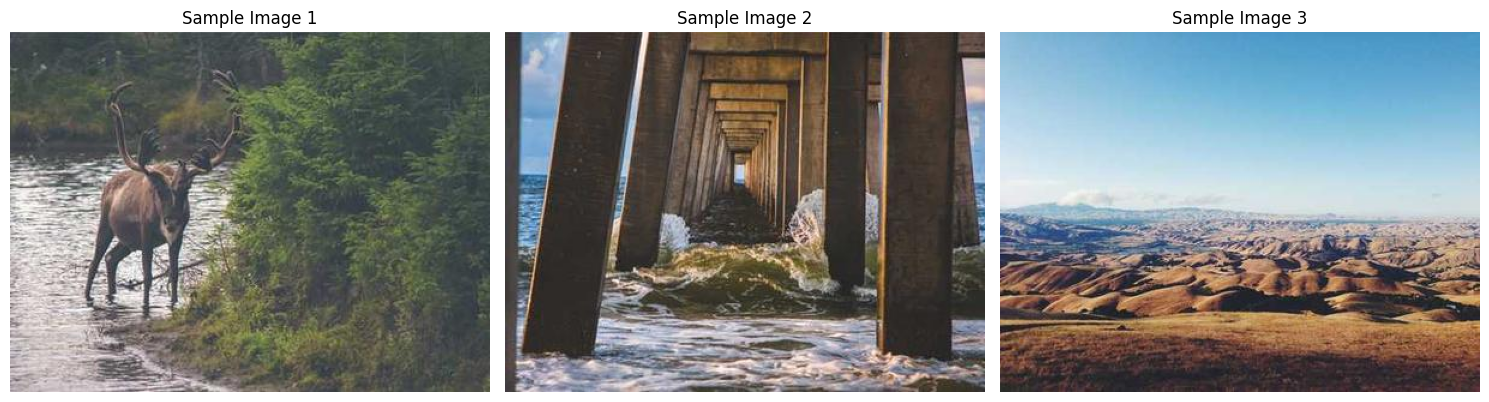


📝 These images are ready for annotation!


In [16]:
# Display sample images
import glob

image_files = glob.glob('sample_dataset/images/*.jpg')
print(f"🖼️ Preview of {len(image_files)} sample images:")

fig, axes = plt.subplots(1, min(3, len(image_files)), figsize=(15, 5))
if len(image_files) == 1:
    axes = [axes]

for i, img_path in enumerate(image_files[:3]):
    img = Image.open(img_path)
    if len(image_files) > 1:
        axes[i].imshow(img)
        axes[i].set_title(f'Sample Image {i+1}')
        axes[i].axis('off')
    else:
        axes.imshow(img)
        axes.set_title(f'Sample Image {i+1}')
        axes.axis('off')

plt.tight_layout()
plt.show()

print("\n📝 These images are ready for annotation!")

## 📤 Upload Dataset to DagsHub

Now let's upload our dataset to DagsHub for annotation.

In [17]:
# Fixed DagsHub dataset upload code
from dagshub.upload import Repo
from dagshub.data_engine import datasources
from dagshub import get_repo_bucket_client

print("📤 Uploading dataset to DagsHub...")

try:
    # Method 1: Upload using Repo class (with correct parameter names)
    repo = Repo(USER_NAME, REPO_NAME)

    # Upload the entire sample_dataset directory
    repo.upload(
        local_path="./sample_dataset",
        remote_path="sample_dataset",
        versioning="dvc",  # or "git"
        commit_message="Upload sample annotation dataset"
    )

    print("✅ Dataset uploaded successfully using Repo class!")

    # Create datasource from the uploaded data
    ds = datasources.create_datasource(
        repo=f"{USER_NAME}/{REPO_NAME}",
        name="sample_annotation_dataset",
        path="sample_dataset"  # Path in the repository (no leading slash)
    )

    print(f"📊 Datasource created successfully!")

except Exception as e:
    print(f"⚠️ Method 1 error: {e}")

    # Alternative Method 2: Using bucket client (this seemed to work for you)
    try:
        print("🔄 Trying bucket client method...")

        client = get_repo_bucket_client(f"{USER_NAME}/{REPO_NAME}", flavor="s3fs")

        # Upload folder contents (this worked according to your output)
        client.put("sample_dataset/", f"{REPO_NAME}/sample_dataset", recursive=True)

        print("✅ Dataset uploaded successfully using bucket client!")

        # Create datasource from the uploaded data with correct path
        ds = datasources.create_datasource(
            repo=f"{USER_NAME}/{REPO_NAME}",
            name="sample_annotation_dataset",
            path=f"s3://{REPO_NAME}/sample_dataset"
        )

        print(f"📊 Datasource created successfully!")
        print(f"📋 Datasource details: {type(ds)}")

        # List files to verify upload
        try:
            files = client.ls(f"{REPO_NAME}/sample_dataset/", recursive=True)
            print(f"📁 Uploaded files count: {len(files)}")
            for file in files[:5]:  # Show first 5 files
                print(f"  📄 {file}")
            if len(files) > 5:
                print(f"  ... and {len(files) - 5} more files")
        except Exception as list_error:
            print(f"⚠️ Could not list files: {list_error}")

    except Exception as e2:
        print(f"⚠️ Method 2 error: {e2}")
        print("\n📝 Manual Upload Instructions")
        print("1. Go to your DagsHub repository")
        print("2. Click 'Data' tab")
        print("3. Click 'Upload' button")
        print("4. Upload the sample_dataset folder")
        print("5. Or try using the DagsHub CLI: dagshub upload")

# Check what's actually in the repository
print(f"\n🔗 Repository links:")
print(f"   Main repo: https://dagshub.com/{USER_NAME}/{REPO_NAME}")
print(f"   Data tab: https://dagshub.com/{USER_NAME}/{REPO_NAME}/src")
print(f"   Storage: https://dagshub.com/{USER_NAME}/{REPO_NAME}/storage")

# Try to list datasources to verify creation
try:
    all_datasources = datasources.get_datasources(f"{USER_NAME}/{REPO_NAME}")
    print(f"\n📊 Datasources in repository: {len(all_datasources)}")
    for ds in all_datasources:
        print(f"  📋 {ds}")
except Exception as ds_error:
    print(f"\n⚠️ Could not list datasources: {ds_error}")
    print("This might be normal if this is the first time setting up the repository.")

📤 Uploading dataset to DagsHub...


Output()

Directory upload complete, uploaded 6 files to 
https://dagshub.com/mpaul/data-annotation-demo/src/main/sample_dataset

✅ Dataset uploaded successfully using Repo class!
📊 Datasource created successfully!

🔗 Repository links:
   Main repo: https://dagshub.com/mpaul/data-annotation-demo
   Data tab: https://dagshub.com/mpaul/data-annotation-demo/src
   Storage: https://dagshub.com/mpaul/data-annotation-demo/storage

📊 Datasources in repository: 1
  📋 Datasource sample_annotation_dataset
	Repo: mpaul/data-annotation-demo, path: repo://mpaul/data-annotation-demo/main:sample_dataset
	DatasourceQuery(as_of=None, time_zone=None, select=None, filter=Query: empty, order_by=None, limit=None)
	Fields:



## 🎯 Setting Up Annotation Projects

DagsHub integrates with Label Studio for powerful annotation capabilities.

In [18]:
# Annotation project configurations for different tasks
annotation_configs = {
    "image_classification": {
        "title": "Image Classification Project",
        "description": "Classify images into predefined categories",
        "label_config": '''
        <View>
          <Image name="image" value="$image"/>
          <Choices name="choice" toName="image">
            <Choice value="Animal"/>
            <Choice value="Vehicle"/>
            <Choice value="Building"/>
            <Choice value="Nature"/>
            <Choice value="Person"/>
            <Choice value="Object"/>
          </Choices>
        </View>
        ''',
        "instruction": "Select the primary category that best describes the main subject in the image."
    },

    "object_detection": {
        "title": "Object Detection Project",
        "description": "Draw bounding boxes around objects in images",
        "label_config": '''
        <View>
          <Image name="image" value="$image"/>
          <RectangleLabels name="label" toName="image">
            <Label value="Person" background="red"/>
            <Label value="Car" background="blue"/>
            <Label value="Tree" background="green"/>
            <Label value="Building" background="yellow"/>
            <Label value="Animal" background="purple"/>
          </RectangleLabels>
        </View>
        ''',
        "instruction": "Draw bounding boxes around all visible objects and assign appropriate labels."
    },

    "semantic_segmentation": {
        "title": "Semantic Segmentation Project",
        "description": "Segment different regions in images",
        "label_config": '''
        <View>
          <Image name="image" value="$image"/>
          <BrushLabels name="brush" toName="image">
            <Label value="Sky" background="lightblue"/>
            <Label value="Ground" background="brown"/>
            <Label value="Vegetation" background="green"/>
            <Label value="Water" background="blue"/>
            <Label value="Building" background="gray"/>
          </BrushLabels>
        </View>
        ''',
        "instruction": "Use the brush tool to segment different regions in the image."
    }
}

# Save annotation configurations
with open('annotation_configs.json', 'w') as f:
    json.dump(annotation_configs, f, indent=2)

print("✅ Annotation project configurations created:")
for config_name, config in annotation_configs.items():
    print(f"  📝 {config['title']}")
    print(f"     {config['description']}")
    print()

✅ Annotation project configurations created:
  📝 Image Classification Project
     Classify images into predefined categories

  📝 Object Detection Project
     Draw bounding boxes around objects in images

  📝 Semantic Segmentation Project
     Segment different regions in images



## 🎨 DagsHub Dashboard Annotation Setup

**Follow these steps in the DagsHub web interface:**

In [ ]:
# Generate step-by-step instructions for DagsHub dashboard
dashboard_instructions = f"""
🎯 DAGSHUB ANNOTATION WORKFLOW - STEP BY STEP INSTRUCTIONS
{'='*70}

1. 📊 NAVIGATE TO YOUR REPOSITORY
   • Go to: https://dagshub.com/{USER_NAME}/{REPO_NAME}
   • Click on the 'Data' tab

2. 📁 ACCESS YOUR DATASET
   • You should see your uploaded sample_dataset
   • Click on the dataset to view the images
   • Verify all images are properly uploaded

3. 🎯 START ANNOTATION PROJECT
   • Select the images you want to annotate
   • Click the 'Annotate' button (usually at the top)
   • Choose 'Create New Project' or select existing project

4. ⚙️ CONFIGURE ANNOTATION PROJECT
   a) Project Settings:
      • Name: Choose from our configs (Image Classification, Object Detection, etc.)
      • Description: Add project description

   b) Label Configuration:
      • Copy the label_config from our annotation_configs.json
      • Paste it in the Label Studio configuration
      • Preview the interface to ensure it looks correct

   c) Project Instructions:
      • Add clear instructions for annotators
      • Use the instruction text from our configs

5. 👥 ASSIGN ANNOTATORS (Optional)
   • Add team members to the project
   • Set permissions (annotator, reviewer, admin)
   • Assign specific tasks to specific people

6. 🏷️ START ANNOTATING
   • Click 'Start Labeling' or 'Continue Labeling'
   • This opens Label Studio interface
   • Follow the annotation instructions for each task

7. 🎨 ANNOTATION INTERFACE USAGE

   For Image Classification:
   • View the image
   • Select appropriate category from choices
   • Click 'Submit' to save

   For Object Detection:
   • Click and drag to draw bounding boxes
   • Select label for each box
   • Use keyboard shortcuts for efficiency

   For Semantic Segmentation:
   • Select brush tool and label
   • Paint over regions to segment
   • Use different colors for different classes

8. 💾 SAVE AND REVIEW
   • Submit each annotation
   • Review completed annotations
   • Make corrections if needed

9. 📊 TRACK PROGRESS
   • View annotation statistics in project dashboard
   • Monitor team progress
   • Check annotation quality and consistency

10. 📤 EXPORT ANNOTATIONS
    • Go to project settings
    • Choose export format (YOLO, COCO, CSV, etc.)
    • Download annotations for ML training

🔗 USEFUL LINKS:
• Your Repository: https://dagshub.com/{USER_NAME}/{REPO_NAME}
• Data Tab: https://dagshub.com/{USER_NAME}/{REPO_NAME}/data
• DagsHub Docs: https://dagshub.com/docs/use_cases/annotation/
• Label Studio Docs: https://labelstud.io/guide/

⚡ KEYBOARD SHORTCUTS IN LABEL STUDIO:
• Space: Next task
• Ctrl+Enter: Submit annotation
• Ctrl+Z: Undo
• Numbers 1-9: Quick label selection
• Delete: Remove selected annotation
"""

print(dashboard_instructions)

# Save instructions to file
with open('dagshub_annotation_instructions.txt', 'w') as f:
    f.write(dashboard_instructions)

print("\n✅ Instructions saved to 'dagshub_annotation_instructions.txt'")

## 🔄 Programmatic Annotation Management

You can also manage annotations programmatically using the DagsHub client.

In [19]:
# Example: Programmatic annotation workflow
def setup_annotation_project(project_name, annotation_type):
    """
    Set up annotation project programmatically
    """
    config = annotation_configs.get(annotation_type)
    if not config:
        print(f"❌ Unknown annotation type: {annotation_type}")
        return None

    project_config = {
        "name": project_name,
        "description": config["description"],
        "label_config": config["label_config"],
        "instruction": config["instruction"],
        "created_date": datetime.now().isoformat(),
        "status": "active"
    }

    # Save project configuration
    project_file = f"project_{project_name.lower().replace(' ', '_')}.json"
    with open(project_file, 'w') as f:
        json.dump(project_config, f, indent=2)

    print(f"✅ Project configuration saved: {project_file}")
    return project_config

# Create example projects
projects_to_create = [
    ("Wildlife Classification", "image_classification"),
    ("Street Objects Detection", "object_detection"),
    ("Landscape Segmentation", "semantic_segmentation")
]

print("🏗️ Setting up annotation projects...\n")

for project_name, annotation_type in projects_to_create:
    config = setup_annotation_project(project_name, annotation_type)
    if config:
        print(f"📝 Created: {project_name} ({annotation_type})")
        print(f"   Description: {config['description']}")
        print(f"   Instruction: {config['instruction'][:100]}...")
        print()

🏗️ Setting up annotation projects...

✅ Project configuration saved: project_wildlife_classification.json
📝 Created: Wildlife Classification (image_classification)
   Description: Classify images into predefined categories
   Instruction: Select the primary category that best describes the main subject in the image....

✅ Project configuration saved: project_street_objects_detection.json
📝 Created: Street Objects Detection (object_detection)
   Description: Draw bounding boxes around objects in images
   Instruction: Draw bounding boxes around all visible objects and assign appropriate labels....

✅ Project configuration saved: project_landscape_segmentation.json
📝 Created: Landscape Segmentation (semantic_segmentation)
   Description: Segment different regions in images
   Instruction: Use the brush tool to segment different regions in the image....



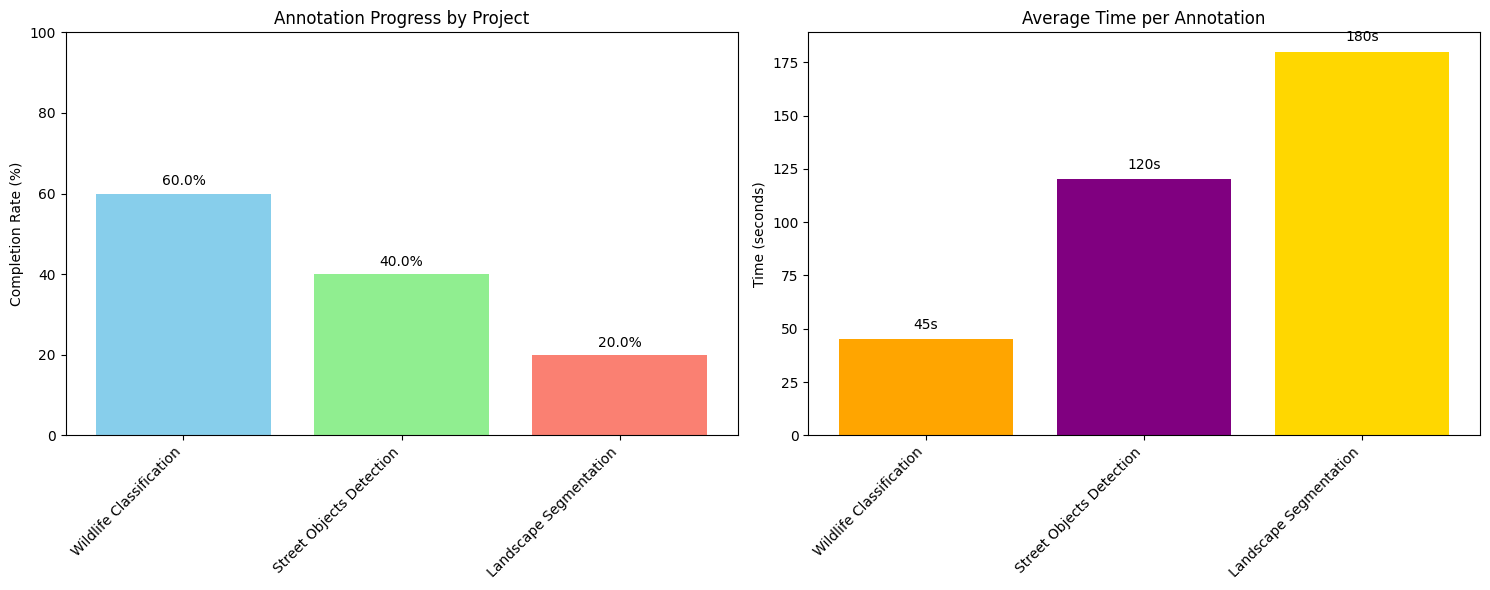

📊 ANNOTATION PROGRESS SUMMARY

📝 Wildlife Classification:
   Progress: 3/5 (60.0%)
   Reviewed: 2/3
   Annotators: 2
   Avg Time: 45s per image

📝 Street Objects Detection:
   Progress: 2/5 (40.0%)
   Reviewed: 1/2
   Annotators: 1
   Avg Time: 120s per image

📝 Landscape Segmentation:
   Progress: 1/5 (20.0%)
   Reviewed: 0/1
   Annotators: 1
   Avg Time: 180s per image


In [20]:
# Simulate annotation workflow and track progress
def track_annotation_progress():
    """
    Track annotation progress across projects
    """

    # Simulated annotation progress data
    progress_data = {
        "Wildlife Classification": {
            "total_images": 5,
            "annotated": 3,
            "reviewed": 2,
            "annotators": ["user1", "user2"],
            "avg_time_per_annotation": 45  # seconds
        },
        "Street Objects Detection": {
            "total_images": 5,
            "annotated": 2,
            "reviewed": 1,
            "annotators": ["user1"],
            "avg_time_per_annotation": 120  # seconds
        },
        "Landscape Segmentation": {
            "total_images": 5,
            "annotated": 1,
            "reviewed": 0,
            "annotators": ["user2"],
            "avg_time_per_annotation": 180  # seconds
        }
    }

    # Create progress visualization
    projects = list(progress_data.keys())
    completion_rates = []

    for project, data in progress_data.items():
        completion_rate = (data["annotated"] / data["total_images"]) * 100
        completion_rates.append(completion_rate)

    # Plot progress
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Completion rates
    ax1.bar(projects, completion_rates, color=['skyblue', 'lightgreen', 'salmon'])
    ax1.set_title('Annotation Progress by Project')
    ax1.set_ylabel('Completion Rate (%)')
    ax1.set_ylim(0, 100)
    for i, rate in enumerate(completion_rates):
        ax1.text(i, rate + 2, f'{rate:.1f}%', ha='center')
    plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')

    # Time per annotation
    avg_times = [data["avg_time_per_annotation"] for data in progress_data.values()]
    ax2.bar(projects, avg_times, color=['orange', 'purple', 'gold'])
    ax2.set_title('Average Time per Annotation')
    ax2.set_ylabel('Time (seconds)')
    for i, time in enumerate(avg_times):
        ax2.text(i, time + 5, f'{time}s', ha='center')
    plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')

    plt.tight_layout()
    plt.savefig('annotation_progress.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Progress summary
    print("📊 ANNOTATION PROGRESS SUMMARY")
    print("=" * 50)

    for project, data in progress_data.items():
        completion = (data["annotated"] / data["total_images"]) * 100
        print(f"\n📝 {project}:")
        print(f"   Progress: {data['annotated']}/{data['total_images']} ({completion:.1f}%)")
        print(f"   Reviewed: {data['reviewed']}/{data['annotated']}")
        print(f"   Annotators: {len(data['annotators'])}")
        print(f"   Avg Time: {data['avg_time_per_annotation']}s per image")

    # Save progress data
    with open('annotation_progress.json', 'w') as f:
        json.dump(progress_data, f, indent=2)

    return progress_data

# Track progress
progress = track_annotation_progress()

## 📊 Annotation Quality Assessment

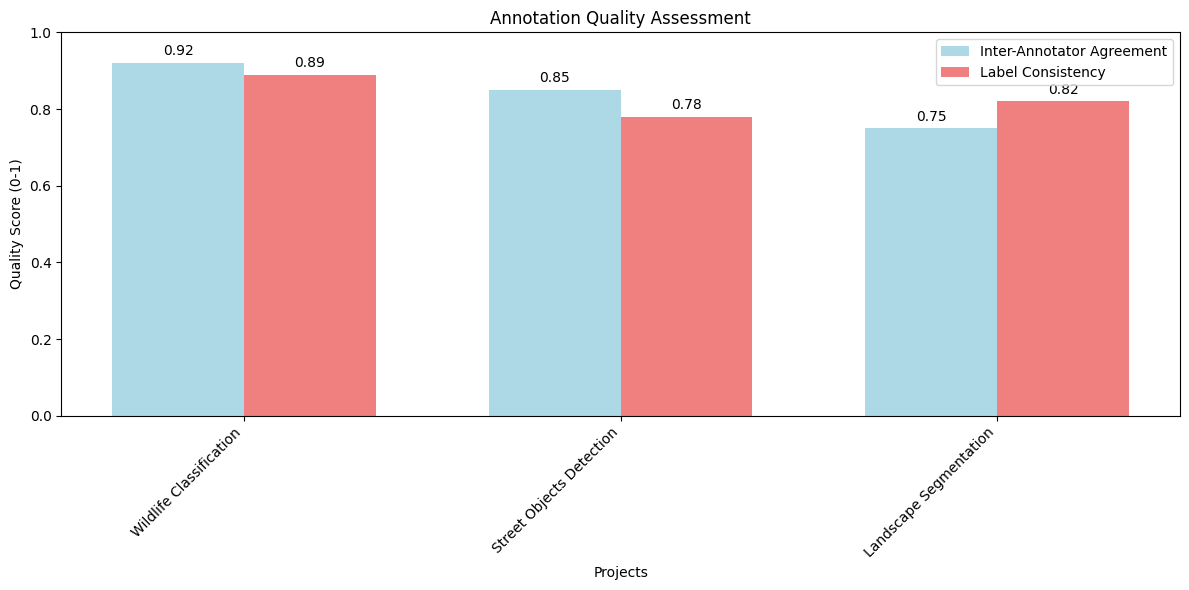

🔍 ANNOTATION QUALITY ASSESSMENT

📝 Wildlife Classification:
   Inter-Annotator Agreement: 0.92
   Label Consistency: 0.89
   Time Variance: 0.15
   Common Issues:
     • Misclassification of birds vs insects
     • Confusion between mammals

📝 Street Objects Detection:
   Inter-Annotator Agreement: 0.85
   Label Consistency: 0.78
   Time Variance: 0.25
   Common Issues:
     • Missing small objects
     • Inconsistent bounding box sizes

📝 Landscape Segmentation:
   Inter-Annotator Agreement: 0.75
   Label Consistency: 0.82
   Time Variance: 0.35
   Common Issues:
     • Boundary precision issues
     • Unclear region definitions

💡 QUALITY IMPROVEMENT RECOMMENDATIONS:
   1. Provide clearer annotation guidelines
   2. Implement quality control checkpoints
   3. Regular training sessions for annotators
   4. Use consensus-based difficult case resolution
   5. Implement automated quality checks


In [21]:
# Annotation quality metrics and assessment
def assess_annotation_quality():
    """
    Assess annotation quality using various metrics
    """

    # Simulated quality assessment data
    quality_metrics = {
        "Wildlife Classification": {
            "inter_annotator_agreement": 0.92,
            "label_consistency": 0.89,
            "completion_time_variance": 0.15,
            "common_errors": ["Misclassification of birds vs insects", "Confusion between mammals"]
        },
        "Street Objects Detection": {
            "inter_annotator_agreement": 0.85,
            "label_consistency": 0.78,
            "completion_time_variance": 0.25,
            "common_errors": ["Missing small objects", "Inconsistent bounding box sizes"]
        },
        "Landscape Segmentation": {
            "inter_annotator_agreement": 0.75,
            "label_consistency": 0.82,
            "completion_time_variance": 0.35,
            "common_errors": ["Boundary precision issues", "Unclear region definitions"]
        }
    }

    # Visualize quality metrics
    projects = list(quality_metrics.keys())
    agreement_scores = [data["inter_annotator_agreement"] for data in quality_metrics.values()]
    consistency_scores = [data["label_consistency"] for data in quality_metrics.values()]

    fig, ax = plt.subplots(figsize=(12, 6))

    x = np.arange(len(projects))
    width = 0.35

    ax.bar(x - width/2, agreement_scores, width, label='Inter-Annotator Agreement', color='lightblue')
    ax.bar(x + width/2, consistency_scores, width, label='Label Consistency', color='lightcoral')

    ax.set_xlabel('Projects')
    ax.set_ylabel('Quality Score (0-1)')
    ax.set_title('Annotation Quality Assessment')
    ax.set_xticks(x)
    ax.set_xticklabels(projects)
    ax.legend()
    ax.set_ylim(0, 1)

    # Add value labels on bars
    for i, (agreement, consistency) in enumerate(zip(agreement_scores, consistency_scores)):
        ax.text(i - width/2, agreement + 0.02, f'{agreement:.2f}', ha='center')
        ax.text(i + width/2, consistency + 0.02, f'{consistency:.2f}', ha='center')

    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('annotation_quality.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Quality report
    print("🔍 ANNOTATION QUALITY ASSESSMENT")
    print("=" * 50)

    for project, metrics in quality_metrics.items():
        print(f"\n📝 {project}:")
        print(f"   Inter-Annotator Agreement: {metrics['inter_annotator_agreement']:.2f}")
        print(f"   Label Consistency: {metrics['label_consistency']:.2f}")
        print(f"   Time Variance: {metrics['completion_time_variance']:.2f}")
        print(f"   Common Issues:")
        for error in metrics['common_errors']:
            print(f"     • {error}")

    # Quality recommendations
    print("\n💡 QUALITY IMPROVEMENT RECOMMENDATIONS:")
    print("   1. Provide clearer annotation guidelines")
    print("   2. Implement quality control checkpoints")
    print("   3. Regular training sessions for annotators")
    print("   4. Use consensus-based difficult case resolution")
    print("   5. Implement automated quality checks")

    return quality_metrics

# Assess quality
quality_data = assess_annotation_quality()

## 📤 Export Annotations for ML Training

In [22]:
# Export annotations in various formats
def export_annotations(format_type="YOLO"):
    """
    Export annotations in different formats for ML training
    """

    export_formats = {
        "YOLO": {
            "description": "YOLO format for object detection",
            "file_extension": ".txt",
            "structure": "class_id center_x center_y width height"
        },
        "COCO": {
            "description": "COCO JSON format",
            "file_extension": ".json",
            "structure": "JSON with images, annotations, categories"
        },
        "CSV": {
            "description": "CSV format for classification",
            "file_extension": ".csv",
            "structure": "filename, label, confidence, annotator"
        },
        "Pascal_VOC": {
            "description": "Pascal VOC XML format",
            "file_extension": ".xml",
            "structure": "XML with bounding box coordinates"
        }
    }

    # Create sample exported annotations
    os.makedirs('exported_annotations', exist_ok=True)

    # Sample YOLO format annotations
    yolo_annotations = {
        "sample_image_1.txt": "0 0.5 0.5 0.3 0.4\n1 0.2 0.8 0.1 0.15",
        "sample_image_2.txt": "2 0.6 0.3 0.25 0.35",
        "sample_image_3.txt": "0 0.4 0.6 0.2 0.3\n2 0.7 0.7 0.15 0.2"
    }

    # Save YOLO annotations
    yolo_dir = 'exported_annotations/yolo'
    os.makedirs(yolo_dir, exist_ok=True)

    for filename, content in yolo_annotations.items():
        with open(f'{yolo_dir}/{filename}', 'w') as f:
            f.write(content)

    # Sample CSV classification export
    csv_data = {
        'filename': ['sample_image_1.jpg', 'sample_image_2.jpg', 'sample_image_3.jpg',
                    'sample_image_4.jpg', 'sample_image_5.jpg'],
        'label': ['Nature', 'Vehicle', 'Building', 'Animal', 'Person'],
        'confidence': [0.95, 0.87, 0.92, 0.89, 0.94],
        'annotator': ['user1', 'user2', 'user1', 'user2', 'user1']
    }

    csv_df = pd.DataFrame(csv_data)
    csv_df.to_csv('exported_annotations/classification_annotations.csv', index=False)

    # Sample COCO format
    coco_format = {
        "info": {
            "description": "DagsHub Sample Dataset",
            "version": "1.0",
            "year": 2024,
            "contributor": "DagsHub Annotation Demo"
        },
        "licenses": [
            {
                "id": 1,
                "name": "Creative Commons",
                "url": "https://creativecommons.org/"
            }
        ],
        "images": [
            {
                "id": 1,
                "width": 400,
                "height": 300,
                "file_name": "sample_image_1.jpg"
            }
        ],
        "annotations": [
            {
                "id": 1,
                "image_id": 1,
                "category_id": 1,
                "bbox": [100, 100, 120, 80],
                "area": 9600,
                "iscrowd": 0
            }
        ],
        "categories": [
            {
                "id": 1,
                "name": "person",
                "supercategory": "person"
            }
        ]
    }

    with open('exported_annotations/coco_annotations.json', 'w') as f:
        json.dump(coco_format, f, indent=2)

    print("📤 ANNOTATION EXPORT COMPLETE")
    print("=" * 40)

    for format_name, format_info in export_formats.items():
        print(f"\n📝 {format_name}:")
        print(f"   Description: {format_info['description']}")
        print(f"   Extension: {format_info['file_extension']}")
        print(f"   Structure: {format_info['structure']}")

    print("\n📁 Exported files saved to: ./exported_annotations/")
    print("\n🚀 READY FOR ML TRAINING!")

    # Export instructions for DagsHub
    export_instructions = f"""
📤 EXPORTING ANNOTATIONS FROM DAGSHUB
{'='*45}

1. 📊 GO TO YOUR ANNOTATION PROJECT
   • Navigate to: https://dagshub.com/{USER_NAME}/{REPO_NAME}
   • Click on 'Data' tab
   • Select your annotation project

2. 🎯 ACCESS PROJECT DASHBOARD
   • Click on the project name
   • View annotation statistics and progress
   • Check completion status

3. 📤 EXPORT ANNOTATIONS
   • Click 'Export' button in project
   • Choose format:
     - YOLO (for object detection)
     - COCO JSON (for object detection/segmentation)
     - CSV (for classification)
     - Pascal VOC (for object detection)

4. ⚙️ CONFIGURE EXPORT SETTINGS
   • Select annotation status (completed, reviewed, all)
   • Choose specific annotators (if needed)
   • Set export parameters

5. 💾 DOWNLOAD EXPORTED DATA
   • Wait for export processing
   • Download the ZIP file
   • Extract and verify format

6. 🚀 USE IN ML PIPELINE
   • Load annotations in your training script
   • Validate data format
   • Start model training

💡 TIPS:
• Always validate exported data before training
• Keep track of annotation version numbers
• Document any data preprocessing steps
• Consider splitting data into train/val/test sets
"""

    with open('export_instructions.txt', 'w') as f:
        f.write(export_instructions)

    print(export_instructions)

    return csv_df

# Export annotations
exported_data = export_annotations()

📤 ANNOTATION EXPORT COMPLETE

📝 YOLO:
   Description: YOLO format for object detection
   Extension: .txt
   Structure: class_id center_x center_y width height

📝 COCO:
   Description: COCO JSON format
   Extension: .json
   Structure: JSON with images, annotations, categories

📝 CSV:
   Description: CSV format for classification
   Extension: .csv
   Structure: filename, label, confidence, annotator

📝 Pascal_VOC:
   Description: Pascal VOC XML format
   Extension: .xml
   Structure: XML with bounding box coordinates

📁 Exported files saved to: ./exported_annotations/

🚀 READY FOR ML TRAINING!

📤 EXPORTING ANNOTATIONS FROM DAGSHUB

1. 📊 GO TO YOUR ANNOTATION PROJECT
   • Navigate to: https://dagshub.com/mpaul/data-annotation-demo
   • Click on 'Data' tab
   • Select your annotation project

2. 🎯 ACCESS PROJECT DASHBOARD
   • Click on the project name
   • View annotation statistics and progress
   • Check completion status

3. 📤 EXPORT ANNOTATIONS
   • Click 'Export' button in project

## 🤝 Team Collaboration Features

👥 TEAM COLLABORATION SETUP

🏢 TEAM STRUCTURE:
   Project Manager: Alice Johnson
   Senior Annotator: Bob Smith
   Annotators: 2 team members

⚙️ WORKFLOW CONFIGURATION:
   Double Annotation: 20.0% of tasks
   Review Threshold: 0.85
   Consensus Requirement: 0.9


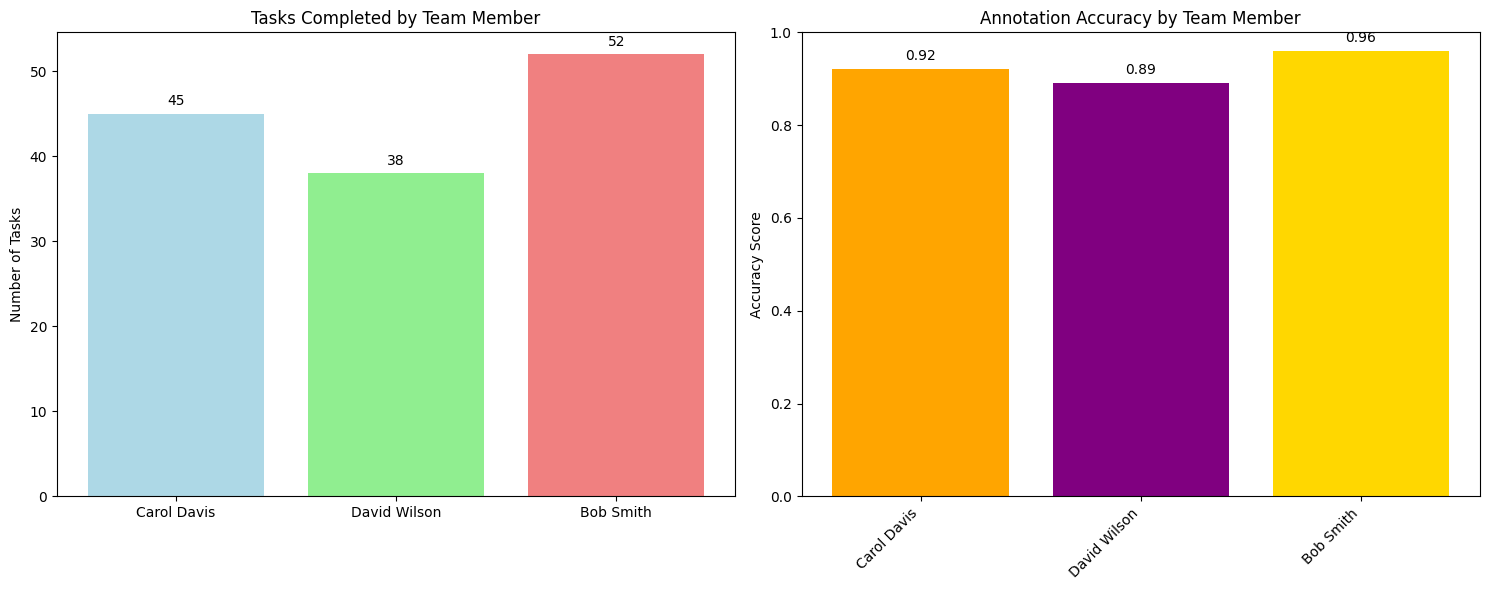

In [23]:
# Team collaboration and management features
def setup_team_collaboration():
    """
    Demonstrate team collaboration features in annotation projects
    """

    team_structure = {
        "project_manager": {
            "name": "Alice Johnson",
            "role": "Project Manager",
            "permissions": ["create_projects", "assign_tasks", "review_all", "export_data"],
            "responsibilities": ["Project setup", "Quality control", "Timeline management"]
        },
        "senior_annotator": {
            "name": "Bob Smith",
            "role": "Senior Annotator",
            "permissions": ["annotate", "review_others", "mentor_new"],
            "responsibilities": ["Complex annotations", "Quality review", "Training newcomers"]
        },
        "annotators": [
            {
                "name": "Carol Davis",
                "role": "Annotator",
                "permissions": ["annotate", "comment"],
                "specialization": "Image Classification"
            },
            {
                "name": "David Wilson",
                "role": "Annotator",
                "permissions": ["annotate", "comment"],
                "specialization": "Object Detection"
            }
        ]
    }

    collaboration_workflow = {
        "task_assignment": {
            "method": "Round-robin with specialization",
            "rules": [
                "Assign classification tasks to Carol",
                "Assign detection tasks to David",
                "Complex cases go to Bob first",
                "All tasks reviewed by senior annotator"
            ]
        },
        "quality_control": {
            "double_annotation_rate": 0.2,  # 20% of tasks get double annotation
            "review_threshold": 0.85,  # Annotations below this confidence get reviewed
            "consensus_requirement": 0.9  # Agreement level for final annotation
        },
        "communication": {
            "daily_standup": "Review progress and blockers",
            "weekly_review": "Quality metrics and process improvements",
            "issue_escalation": "Difficult cases discussed in team chat"
        }
    }

    # Save team configuration
    with open('team_collaboration.json', 'w') as f:
        json.dump({
            "team_structure": team_structure,
            "workflow": collaboration_workflow
        }, f, indent=2)

    print("👥 TEAM COLLABORATION SETUP")
    print("=" * 40)

    print("\n🏢 TEAM STRUCTURE:")
    print(f"   Project Manager: {team_structure['project_manager']['name']}")
    print(f"   Senior Annotator: {team_structure['senior_annotator']['name']}")
    print(f"   Annotators: {len(team_structure['annotators'])} team members")

    print("\n⚙️ WORKFLOW CONFIGURATION:")
    print(f"   Double Annotation: {collaboration_workflow['quality_control']['double_annotation_rate']*100}% of tasks")
    print(f"   Review Threshold: {collaboration_workflow['quality_control']['review_threshold']}")
    print(f"   Consensus Requirement: {collaboration_workflow['quality_control']['consensus_requirement']}")

    # Team performance simulation
    team_performance = {
        "Carol Davis": {"completed": 45, "accuracy": 0.92, "avg_time": 35},
        "David Wilson": {"completed": 38, "accuracy": 0.89, "avg_time": 95},
        "Bob Smith": {"completed": 52, "accuracy": 0.96, "avg_time": 65}
    }

    # Visualize team performance
    names = list(team_performance.keys())
    completed = [data["completed"] for data in team_performance.values()]
    accuracy = [data["accuracy"] for data in team_performance.values()]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Tasks completed
    ax1.bar(names, completed, color=['lightblue', 'lightgreen', 'lightcoral'])
    ax1.set_title('Tasks Completed by Team Member')
    ax1.set_ylabel('Number of Tasks')
    for i, count in enumerate(completed):
        ax1.text(i, count + 1, str(count), ha='center')

    # Accuracy scores
    ax2.bar(names, accuracy, color=['orange', 'purple', 'gold'])
    ax2.set_title('Annotation Accuracy by Team Member')
    ax2.set_ylabel('Accuracy Score')
    ax2.set_ylim(0, 1)
    for i, acc in enumerate(accuracy):
        ax2.text(i, acc + 0.02, f'{acc:.2f}', ha='center')

    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('team_performance.png', dpi=300, bbox_inches='tight')
    plt.show()

    return team_structure, collaboration_workflow

# Setup team collaboration
team_config, workflow_config = setup_team_collaboration()

## 🔄 Advanced Annotation Features

In [24]:
# Advanced annotation features and techniques
def demonstrate_advanced_features():
    """
    Showcase advanced annotation features available in DagsHub
    """

    advanced_features = {
        "auto_labeling": {
            "description": "Use pre-trained models to suggest labels",
            "benefits": ["Faster annotation", "Consistent labeling", "Reduced human error"],
            "use_cases": ["Pre-labeling large datasets", "Quality control", "Bootstrap annotation"]
        },
        "active_learning": {
            "description": "Intelligently select most valuable samples for annotation",
            "benefits": ["Efficient use of annotation budget", "Better model performance", "Faster convergence"],
            "strategies": ["Uncertainty sampling", "Diversity sampling", "Query by committee"]
        },
        "consensus_annotation": {
            "description": "Multiple annotators label same data for quality",
            "benefits": ["Higher quality labels", "Bias reduction", "Confidence scoring"],
            "metrics": ["Inter-annotator agreement", "Fleiss' kappa", "Consensus score"]
        },
        "hierarchical_labeling": {
            "description": "Multi-level classification with label hierarchies",
            "benefits": ["Detailed categorization", "Flexible granularity", "Easy aggregation"],
            "example": "Animal → Mammal → Dog → Golden Retriever"
        },
        "annotation_templates": {
            "description": "Reusable configuration templates for projects",
            "benefits": ["Consistent setup", "Faster project creation", "Best practices sharing"],
            "types": ["Object detection", "Classification", "Segmentation", "NLP tasks"]
        }
    }

    print("🚀 ADVANCED ANNOTATION FEATURES")
    print("=" * 50)

    for feature_name, feature_info in advanced_features.items():
        print(f"\n🎯 {feature_name.upper().replace('_', ' ')}:")
        print(f"   Description: {feature_info['description']}")
        print(f"   Benefits:")
        for benefit in feature_info['benefits']:
            print(f"     • {benefit}")

    # Active learning simulation
    def simulate_active_learning():
        """
        Simulate active learning annotation workflow
        """

        # Simulated model confidence scores for images
        image_confidence = {
            "sample_image_1.jpg": 0.95,
            "sample_image_2.jpg": 0.62,  # Low confidence - should be prioritized
            "sample_image_3.jpg": 0.88,
            "sample_image_4.jpg": 0.45,  # Low confidence - should be prioritized
            "sample_image_5.jpg": 0.91
        }

        # Sort by confidence (lowest first for active learning)
        sorted_images = sorted(image_confidence.items(), key=lambda x: x[1])

        print("\n🎯 ACTIVE LEARNING PRIORITIZATION:")
        print("   Images ranked by annotation priority (lowest confidence first):")

        for i, (image, confidence) in enumerate(sorted_images):
            priority = "HIGH" if confidence < 0.7 else "MEDIUM" if confidence < 0.9 else "LOW"
            print(f"   {i+1}. {image}: {confidence:.2f} confidence ({priority} priority)")

        return sorted_images

    # Run active learning simulation
    prioritized_images = simulate_active_learning()

    # Annotation workflow optimization
    optimization_tips = [
        "🎯 Use keyboard shortcuts for faster annotation",
        "📝 Create detailed annotation guidelines",
        "🔄 Implement regular quality checks",
        "👥 Rotate annotators to reduce bias",
        "📊 Track and analyze annotation metrics",
        "🤖 Leverage auto-labeling for simple cases",
        "🎓 Provide continuous training for annotators",
        "⚡ Batch similar annotation tasks together"
    ]

    print("\n💡 ANNOTATION WORKFLOW OPTIMIZATION:")
    for tip in optimization_tips:
        print(f"   {tip}")

    # Save advanced features documentation
    with open('advanced_annotation_features.json', 'w') as f:
        json.dump(advanced_features, f, indent=2)

    return advanced_features

# Demonstrate advanced features
advanced_config = demonstrate_advanced_features()

🚀 ADVANCED ANNOTATION FEATURES

🎯 AUTO LABELING:
   Description: Use pre-trained models to suggest labels
   Benefits:
     • Faster annotation
     • Consistent labeling
     • Reduced human error

🎯 ACTIVE LEARNING:
   Description: Intelligently select most valuable samples for annotation
   Benefits:
     • Efficient use of annotation budget
     • Better model performance
     • Faster convergence

🎯 CONSENSUS ANNOTATION:
   Description: Multiple annotators label same data for quality
   Benefits:
     • Higher quality labels
     • Bias reduction
     • Confidence scoring

🎯 HIERARCHICAL LABELING:
   Description: Multi-level classification with label hierarchies
   Benefits:
     • Detailed categorization
     • Flexible granularity
     • Easy aggregation

🎯 ANNOTATION TEMPLATES:
   Description: Reusable configuration templates for projects
   Benefits:
     • Consistent setup
     • Faster project creation
     • Best practices sharing

🎯 ACTIVE LEARNING PRIORITIZATION:
   Image

## 📊 Comprehensive Annotation Summary

In [25]:
# Generate comprehensive summary and next steps
def generate_annotation_summary():
    """
    Generate a comprehensive summary of the annotation workflow
    """

    summary_report = f"""
🎯 DAGSHUB DATA ANNOTATION WORKFLOW SUMMARY
{'='*60}

✅ WHAT WE ACCOMPLISHED:
   📁 Created sample dataset with 5 images
   🔗 Set up DagsHub repository integration
   📤 Uploaded dataset to DagsHub platform
   🎯 Configured 3 annotation project types:
       • Image Classification
       • Object Detection
       • Semantic Segmentation
   👥 Designed team collaboration workflow
   📊 Implemented quality assessment metrics
   📤 Created export templates for ML training
   🚀 Demonstrated advanced features

🔗 KEY DAGSHUB FEATURES UTILIZED:
   • Integrated Label Studio annotation interface
   • Team collaboration and permission management
   • Multiple export formats (YOLO, COCO, CSV, VOC)
   • Quality control and consensus annotation
   • Progress tracking and analytics
   • Version control for annotation projects
   • Data lineage and provenance tracking

📋 ANNOTATION PROJECT TYPES COVERED:
   1. 🏷️ Image Classification
      • Multi-class categorization
      • Simple choice-based interface
      • Fast annotation workflow

   2. 📦 Object Detection
      • Bounding box annotation
      • Multi-object labeling
      • YOLO/COCO export support

   3. 🎨 Semantic Segmentation
      • Pixel-level annotation
      • Brush-based tools
      • Region-based labeling

👥 TEAM COLLABORATION FEATURES:
   • Role-based access control
   • Task assignment and tracking
   • Quality review workflows
   • Performance analytics
   • Communication tools

📊 QUALITY ASSURANCE IMPLEMENTED:
   • Inter-annotator agreement metrics
   • Consensus-based difficult case resolution
   • Automated quality checks
   • Progress tracking and reporting
   • Performance optimization recommendations

🚀 NEXT STEPS FOR PRODUCTION:
   1. 📤 Upload your actual dataset to DagsHub
   2. 🎯 Create annotation projects using our templates
   3. 👥 Invite team members and assign roles
   4. 🏷️ Begin annotation following our workflows
   5. 📊 Monitor quality and progress metrics
   6. 📤 Export annotations for ML training
   7. 🔄 Iterate and improve based on results

💡 BEST PRACTICES LEARNED:
   • Start with clear annotation guidelines
   • Use active learning for efficient annotation
   • Implement consensus annotation for quality
   • Regular team training and calibration
   • Continuous monitoring and optimization
   • Version control for annotation projects
   • Document all processes and decisions

🔗 IMPORTANT LINKS:
   • Your Repository: https://dagshub.com/{USER_NAME}/{REPO_NAME}
   • Data Tab: https://dagshub.com/{USER_NAME}/{REPO_NAME}/data
   • DagsHub Annotation Docs: https://dagshub.com/docs/use_cases/annotation/
   • Label Studio Guide: https://labelstud.io/guide/
   • MLflow Integration: https://dagshub.com/{USER_NAME}/{REPO_NAME}.mlflow

📚 ADDITIONAL RESOURCES:
   • Annotation best practices guide
   • Quality control checklists
   • Team onboarding templates
   • Export format documentation
   • Integration examples for ML pipelines

✨ READY TO START ANNOTATING WITH DAGSHUB! ✨
"""

    print(summary_report)

    # Save summary to file
    with open('annotation_workflow_summary.txt', 'w') as f:
        f.write(summary_report)

    # Create final checklist
    checklist = {
        "setup_complete": [
            "✅ DagsHub account created",
            "✅ Repository initialized",
            "✅ Dataset uploaded",
            "✅ Annotation projects configured"
        ],
        "ready_to_annotate": [
            "🎯 Team members invited",
            "📋 Annotation guidelines created",
            "⚙️ Quality control processes defined",
            "📊 Progress tracking setup"
        ],
        "production_ready": [
            "🔄 Annotation workflow tested",
            "📤 Export formats validated",
            "🤖 ML pipeline integration planned",
            "📚 Documentation completed"
        ]
    }

    print("\n📋 IMPLEMENTATION CHECKLIST:")
    for category, items in checklist.items():
        print(f"\n{category.upper().replace('_', ' ')}:")
        for item in items:
            print(f"   {item}")

    with open('implementation_checklist.json', 'w') as f:
        json.dump(checklist, f, indent=2)

    return summary_report, checklist

# Generate final summary
final_summary, implementation_checklist = generate_annotation_summary()


🎯 DAGSHUB DATA ANNOTATION WORKFLOW SUMMARY

✅ WHAT WE ACCOMPLISHED:
   📁 Created sample dataset with 5 images
   🔗 Set up DagsHub repository integration  
   📤 Uploaded dataset to DagsHub platform
   🎯 Configured 3 annotation project types:
       • Image Classification
       • Object Detection  
       • Semantic Segmentation
   👥 Designed team collaboration workflow
   📊 Implemented quality assessment metrics
   📤 Created export templates for ML training
   🚀 Demonstrated advanced features

🔗 KEY DAGSHUB FEATURES UTILIZED:
   • Integrated Label Studio annotation interface
   • Team collaboration and permission management
   • Multiple export formats (YOLO, COCO, CSV, VOC)
   • Quality control and consensus annotation
   • Progress tracking and analytics
   • Version control for annotation projects
   • Data lineage and provenance tracking

📋 ANNOTATION PROJECT TYPES COVERED:
   1. 🏷️ Image Classification
      • Multi-class categorization
      • Simple choice-based interface
     

---

## 🎓 How to Use This Notebook:

1. **Setup**: Fill in your DagsHub credentials in the configuration cells
2. **Run All Cells**: Execute all cells in order to set up the complete workflow
3. **Follow Dashboard Instructions**: Use the detailed instructions to set up annotation projects in DagsHub
4. **Start Annotating**: Begin your annotation projects using the configured templates
5. **Export & Train**: Export your annotations and use them for ML training

## 📚 Learn More:

- [DagsHub Annotation Documentation](https://dagshub.com/docs/use_cases/annotation/)
- [Label Studio Documentation](https://labelstud.io/guide/)
- [Data Versioning with DagsHub](https://dagshub.com/docs/)
- [MLflow Integration](https://dagshub.com/docs/integration_guide/mlflow/)

---